In [1]:
import torch
import sys
import time

sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")
from utilities.visualization import rgb, panelize
from polar_highlighter import PolarHighlighter

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    curr_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(curr_device)
    print(f"CUDA is available: {num_devices} device(s) detected.")
    print(f"Current device id: {curr_device} - {device_name}")
else:
    print("CUDA is not available")
%load_ext autoreload
%autoreload 2


CUDA is available: 1 device(s) detected.
Current device id: 0 - NVIDIA A40


In [74]:
from main import load_and_process_config
from models_utils import load_best_model_by_run
from dataset import from_config
from utilities import tensor_dict_summarize


config = load_and_process_config("config_train.yaml")
config.RUN = "curious-moon-751"
config.DATASETS = {"PSD": config.DATASETS.PSD}

dataset = from_config(config)["validation"]
idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False))
model = load_best_model_by_run(config.RUN).eval()

DATASET  [23:24:50] Processing 1 datasets: ['PSD']

DATASET  [23:24:50] Using dataset-specific TRAIN_SCENES for PSD: PSD_Train

DATASET  [23:24:50]   ✓ Created training dataset for PSD: 361 samples from specific scenes

DATASET  [23:24:50]   ✓ Created validation dataset for PSD: 471 samples from 7 scenes

DATASET  [23:24:50] === Dataset Creation Summary ===

...

MODEL    [23:24:54] Decoder 'diffuse' un-frozen due to DECODER_LR=0.0001

MODEL    [23:24:54] Decoder 'highlight' un-frozen due to DECODER_LR=0.0005

MODEL    [23:24:55] ✓ Token Inpainter: Successfully loaded all 78 state dict keys from weights/token_inpainter.pth

MODEL    [23:24:55] Loaded pretrained token inpainter weights from weights/token_inpainter.pth

MODEL    [23:24:55] Model with class UnReflect_Model_TokenInpainter created with 498,003,972 parameters

INFO     [23:24:55] Found valid run to resume: 
/anvme/workspace/v120bb18-unreflectanything/results/morning-energy-747

INFO     [23:24:55] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/morning-energy-747/models/weights_best.pt

INFO     [23:24:55] Latest epoch: 1

MODEL    [23:24:57] ✓ Decoder 'diffuse': Successfully loaded all 54 state dict keys from weights/rgb_decoder.pth

MODEL    [23:24:57] Loaded pre-trained decoder weights from weights/rgb_decoder.pth

MODEL    [23:24:57] Decoder 'diffuse' un-frozen due to DECODER_LR=0.0001

MODEL    [23:24:57] Decoder 'highlight' un-frozen due to DECODER_LR=0.0005

MODEL    [23:24:58] ✓ Token Inpainter: Successfully loaded all 78 state dict keys from weights/token_inpainter.pth

MODEL    [23:24:58] Loaded pretrained token inpainter weights from weights/token_inpainter.pth

MODEL    [23:24:58] Model with class UnReflect_Model_TokenInpainter created with 498,003,972 parameters

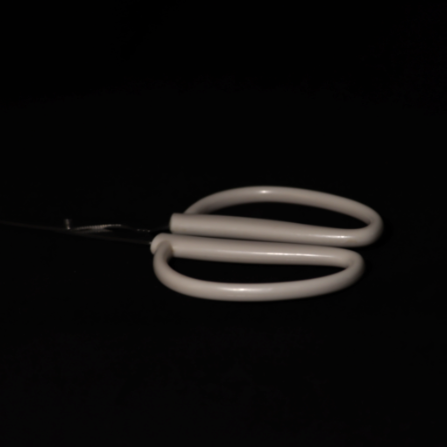

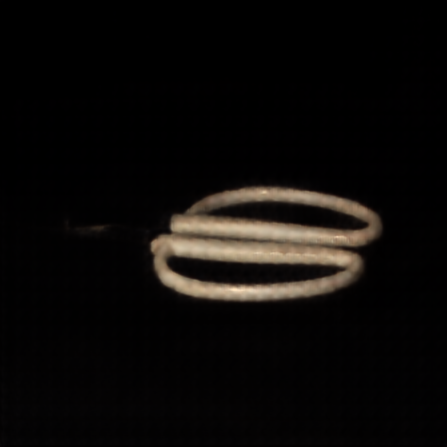

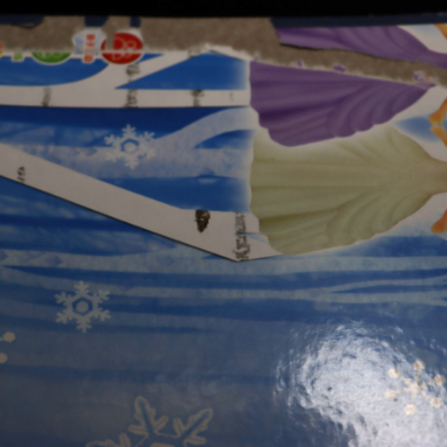

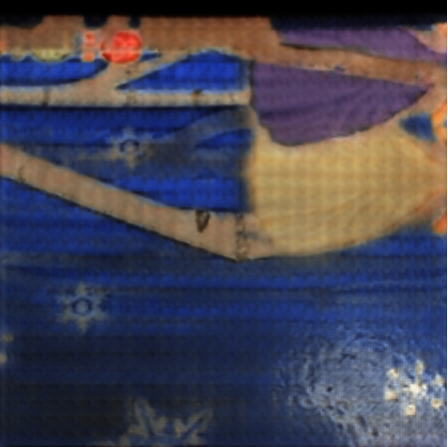

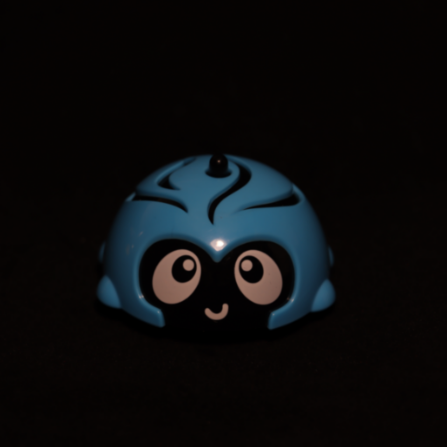

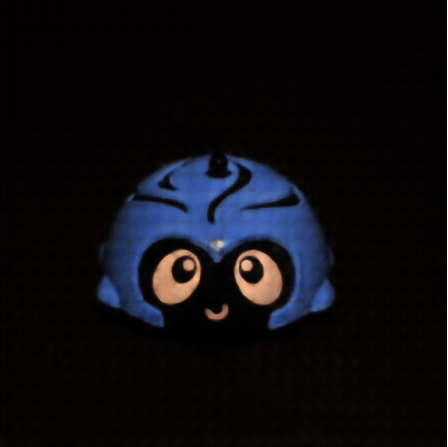

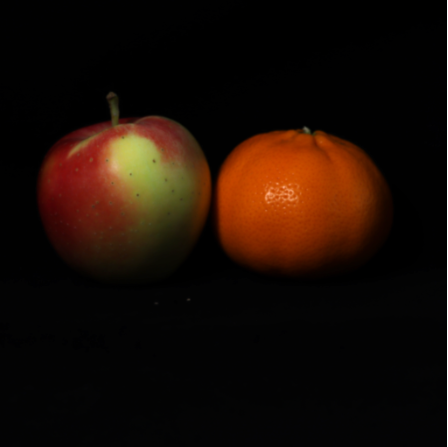

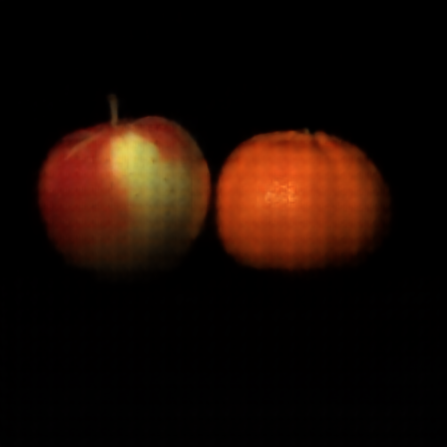

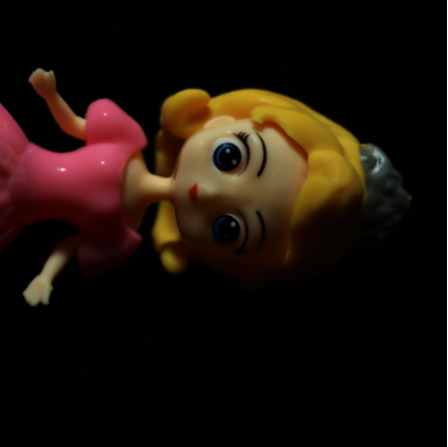

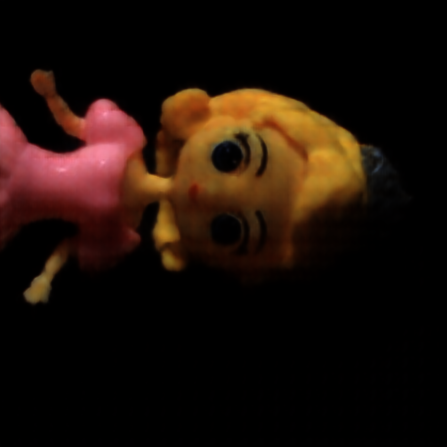

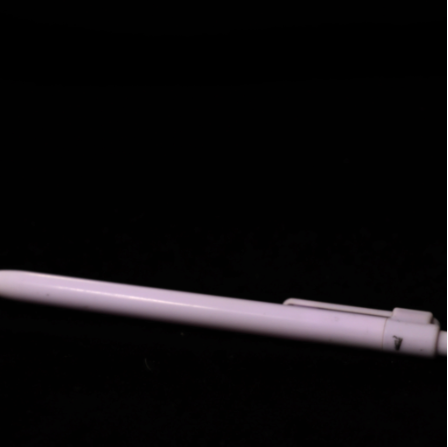

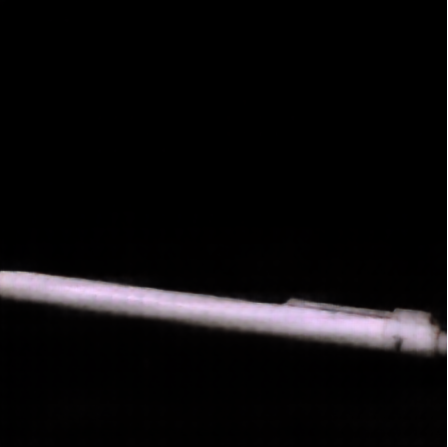

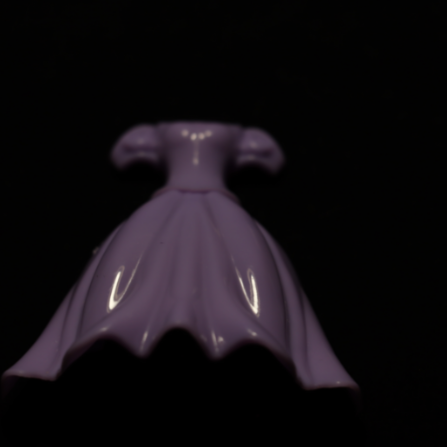

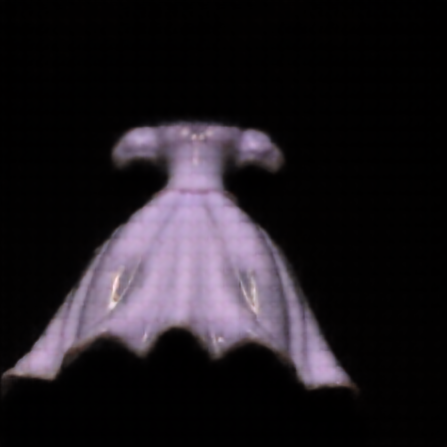

In [ ]:
import importlib
import models
importlib.reload(models)
config = load_and_process_config("config_train.yaml")
config.RUN = "morning-energy-747"
model = load_best_model_by_run(config.RUN).eval()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

for b, batch in enumerate(dataloader):
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    patch_mask = batch["raw"].mean(dim=1, keepdim=True) > 0.9*batch["raw"].mean(dim=1).max().item()
    # model_input = {"rgb": batch["raw"], "inpaint_mask_override": patch_mask}
    model_input = {"rgb": batch["raw"]}
    
    with torch.no_grad():
        modelout = model(model_input)
    rgb(batch["raw"][0], as_tensor=False, resize=(448, 448)),
    rgb(modelout["diffuse"][0], as_tensor=False, resize=(448, 448)),
    # rgb(
    #     panelize(
    #         rgb(batch["raw"][0], as_tensor=True, resize=(448, 448)),
    #         rgb(modelout["diffuse"][0], as_tensor=True, resize=(448, 448)),
    #         rgb(modelout["highlight"][0], as_tensor=True, resize=(448, 448), colormap="gray"),
    #         # rgb(patch_mask.int()[0], as_tensor=True, resize=(448, 448), colormap="gray"),
    #     )
    # )
    if b > 20:
        break
    


In [ ]:
    _, pca = rgb(
        modelout["tokens_completed"][-1].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2),
        as_tensor=True,
        resize=(448, 448),
        blackout=True,
        return_pca=True,
    )
    
    rgb(
        panelize(
            rgb(batch["raw"][0], as_tensor=True, resize=(448, 448)),
            # rgb(
            #     modelout["tokens_completed"][-1]
            #     .reshape(1, 28, 28, 1024)
            #     .permute(0, 3, 1, 2),
            #     as_tensor=True,
            #     pca=pca,
            #     resize=(448, 448),
            # ),
            # rgb(
            #     modelout["tokens_completed"][-1]
            #     .reshape(1, 28, 28, 1024)
            #     .permute(0, 3, 1, 2)
            #     * torch.logical_not(modelout["patch_mask"].reshape(1, 1, 28, 28)),
            #     as_tensor=True,
            #     resize=(448, 448),
            #     pca=pca,
            #     blackout=True,
            # ),
            rgb(modelout["diffuse"][0], as_tensor=True, resize=(448, 448)),
            rgb(modelout["highlight"][0], as_tensor=True, resize=(448, 448)),
        )
    )
    if b > 3:
        break


In [5]:
config = load_and_process_config("config_train.yaml")
config.RUN = "curious-moon-751"
config.DATASETS = {"PSD": config.DATASETS.PSD}
dataset = from_config(config)["validation"]
idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False))
model = load_best_model_by_run(config.RUN).eval()
model.token_inpaint._prior_kernel = 5


DATASET  [18:24:52] Processing 1 datasets: ['PSD']

DATASET  [18:24:52] Using dataset-specific TRAIN_SCENES for PSD: PSD_Train

DATASET  [18:24:52]   ✓ Created training dataset for PSD: 361 samples from specific scenes

DATASET  [18:24:52]   ✓ Created validation dataset for PSD: 471 samples from 7 scenes

DATASET  [18:24:52] === Dataset Creation Summary ===

...

MODEL    [18:24:56] Decoder 'diffuse' un-frozen due to DECODER_LR=0.0001

MODEL    [18:24:56] Decoder 'highlight' un-frozen due to DECODER_LR=0.0005

MODEL    [18:24:56] ✓ Token Inpainter: Successfully loaded all 78 state dict keys from weights/token_inpainter.pth

MODEL    [18:24:56] Loaded pretrained token inpainter weights from weights/token_inpainter.pth

MODEL    [18:24:56] Model with class UnReflect_Model_TokenInpainter created with 498,003,972 parameters

In [6]:
print(model.token_inpaint._prior_kernel)

5


In [ ]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)

for b, batch in enumerate(dataloader):
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    
    patch_mask = batch["raw"].mean(dim=1, keepdim=True) > 0.8
    model_input = {"rgb": batch["raw"]} #, "inpaint_mask_override": patch_mask}
    
    with torch.no_grad():
        modelout = model(model_input)
    _, pca = rgb(
        modelout["tokens_completed"][-1].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2),
        as_tensor=True,
        resize=(448, 448),
        blackout=True,
        return_pca=True,
    )
    rgb(
        panelize(
            rgb(batch["raw"][0], as_tensor=True, resize=(448, 448)),
            # rgb(
            #     modelout["tokens_completed"][-1]
            #     .reshape(1, 28, 28, 1024)
            #     .permute(0, 3, 1, 2),
            #     as_tensor=True,
            #     pca=pca,
            #     resize=(448, 448),
            # ),
            # rgb(
            #     modelout["tokens_completed"][-1]
            #     .reshape(1, 28, 28, 1024)
            #     .permute(0, 3, 1, 2)
            #     * torch.logical_not(modelout["patch_mask"].reshape(1, 1, 28, 28)),
            #     as_tensor=True,
            #     resize=(448, 448),
            #     pca=pca,
            #     blackout=True,
            # ),
            rgb(modelout["diffuse"][0], as_tensor=True, resize=(448, 448)),
            rgb(modelout["highlight"][0], as_tensor=True, resize=(448, 448)),
        )
    )
    if b > 3:
        break


INFO     [18:25:03] Found valid run to resume: /anvme/workspace/v120bb18-unreflectanything/results/curious-moon-751

INFO     [18:25:03] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/curious-moon-751/models/weights_best.pt

INFO     [18:25:03] Latest epoch: 12

MODEL    [18:25:05] ✓ Decoder 'diffuse': Successfully loaded all 54 state dict keys from weights/rgb_decoder.pth

MODEL    [18:25:05] Loaded pre-trained decoder weights from weights/rgb_decoder.pth

MODEL    [18:25:05] Decoder 'diffuse' un-frozen due to DECODER_LR=0.0001

MODEL    [18:25:06] Decoder 'highlight' un-frozen due to DECODER_LR=0.0005

MODEL    [18:25:06] ✓ Token Inpainter: Successfully loaded all 78 state dict keys from weights/token_inpainter.pth

MODEL    [18:25:06] Loaded pretrained token inpainter weights from weights/token_inpainter.pth

MODEL    [18:25:06] Model with class UnReflect_Model_TokenInpainter created with 498,003,972 parameters

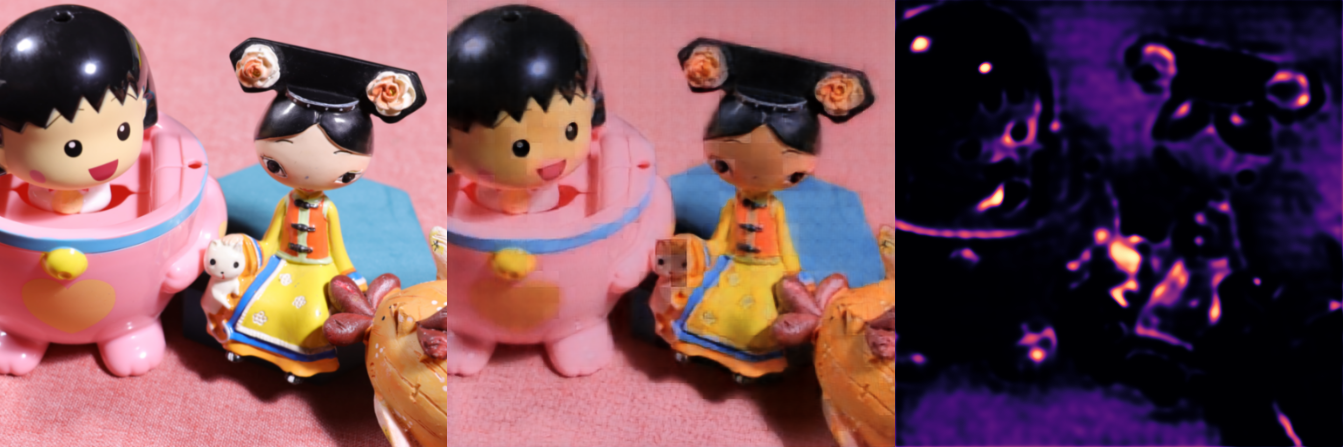

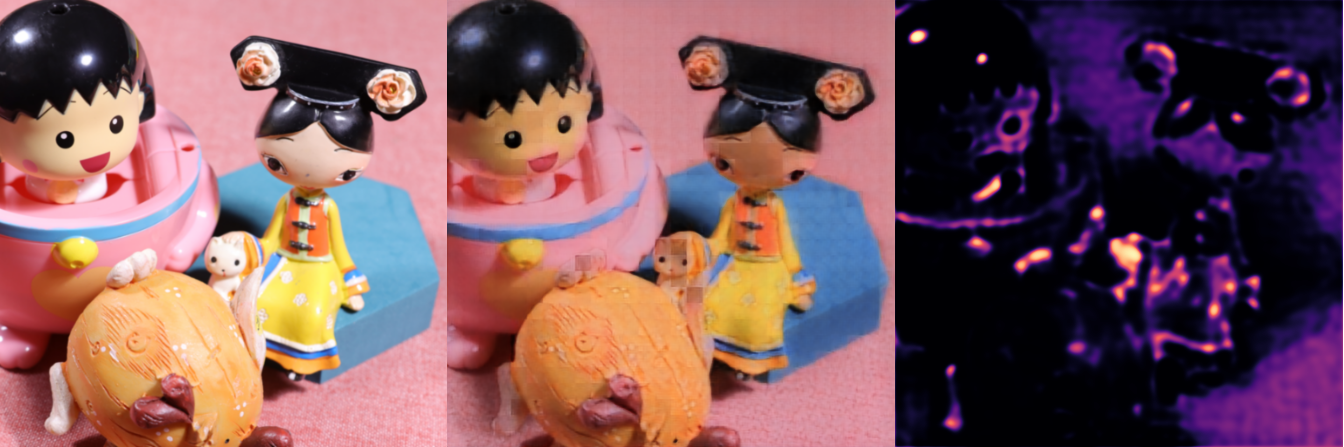

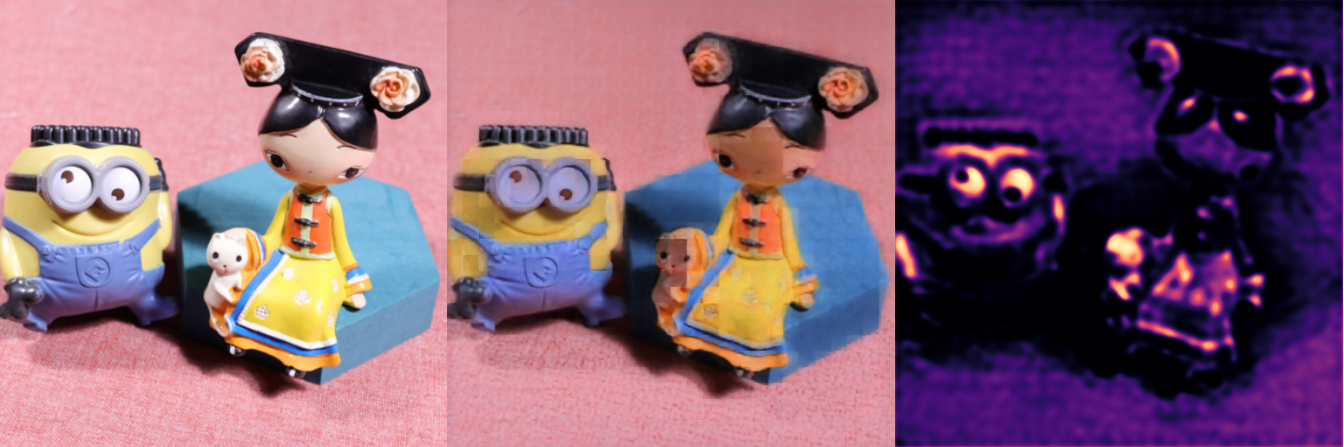

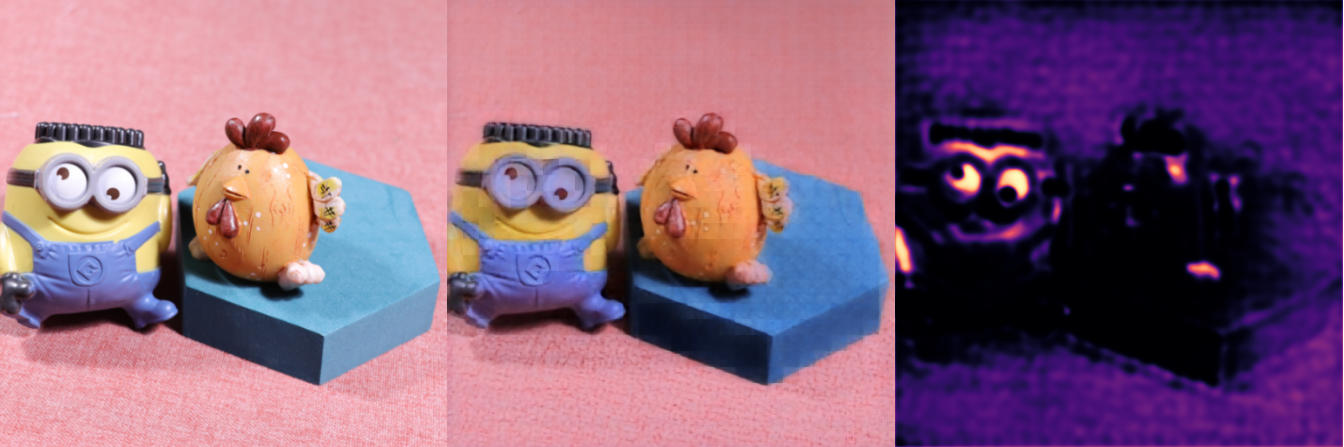

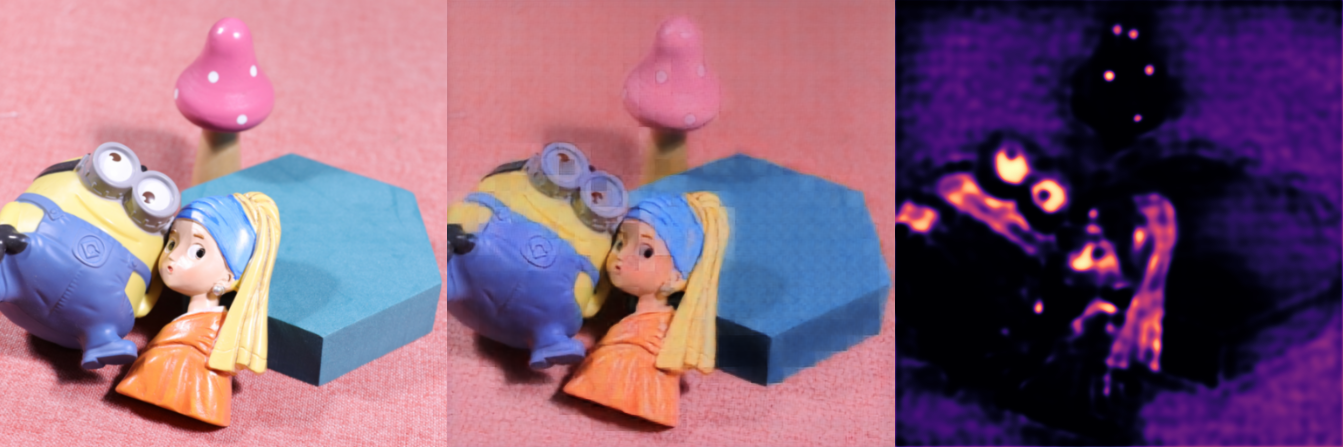

In [8]:
config = load_and_process_config("config_train.yaml")
config.RUN = "curious-moon-751"

# config.DATASETS = {"PSD": config.DATASETS.PSD}
# dataset = from_config(config)["validation"]
# idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False))
model = load_best_model_by_run(config.RUN).eval()
# model.token_inpaint._prior_kernel = 11

dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)

for b, batch in enumerate(dataloader):
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    
    patch_mask = batch["raw"].mean(dim=1, keepdim=True) > 0.8
    model_input = {"rgb": batch["raw"]} #, "inpaint_mask_override": patch_mask}
    
    with torch.no_grad():
        modelout = model(model_input)
    _, pca = rgb(
        modelout["tokens_completed"][-1].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2),
        as_tensor=True,
        resize=(448, 448),
        blackout=True,
        return_pca=True,
    )
    rgb(
        panelize(
            rgb(batch["raw"][0], as_tensor=True, resize=(448, 448)),
            # rgb(
            #     modelout["tokens_completed"][-1]
            #     .reshape(1, 28, 28, 1024)
            #     .permute(0, 3, 1, 2),
            #     as_tensor=True,
            #     pca=pca,
            #     resize=(448, 448),
            # ),
            # rgb(
            #     modelout["tokens_completed"][-1]
            #     .reshape(1, 28, 28, 1024)
            #     .permute(0, 3, 1, 2)
            #     * torch.logical_not(modelout["patch_mask"].reshape(1, 1, 28, 28)),
            #     as_tensor=True,
            #     resize=(448, 448),
            #     pca=pca,
            #     blackout=True,
            # ),
            rgb(modelout["diffuse"][0], as_tensor=True, resize=(448, 448)),
            rgb(modelout["highlight"][0], as_tensor=True, resize=(448, 448)),
        )
    )
    if b > 3:
        break


In [ ]:
# torch.save(model.token_inpaint.state_dict(), "/home/atuin/v120bb/v120bb18/UnReflectAnything/weights/token_inpainter.pth")